Using device: cuda
MUDRA GESTURE RECOGNITION WITH TRANSFORMER

Hyperparameters:
  Sequence Length: 10
  Model Dimension: 128
  Attention Heads: 8
  Encoder Layers: 4
  Learning Rate: 0.001

Data Augmentation:
  Enabled: True
  Gaussian Noise Std: 0.08
  Augmented Copies: 4
  Total Augmentation Factor: 5x

--------------------------------------------------------------------------------
STEP 1: DATA LOADING AND PREPROCESSING
--------------------------------------------------------------------------------

Columns used for training: ['R_PositionX', 'R_PositionY', 'R_PositionZ', 'R_RotationX', 'R_RotationY', 'R_RotationZ', 'R_RotationW', 'R_CurlIndex', 'R_CurlMiddle', 'R_CurlRing', 'R_CurlPinky', 'R_CurlThumb']


C:\Users\drodm\AppData\Local\Temp\ipykernel_29340\2403418275.py:143: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')
C:\Users\drodm\AppData\Local\Temp\ipykernel_29340\2403418275.py:144: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill')


Feature shape: (32001, 12)
Number of features: 12
Label encoder saved with 13 classes: ['Abhaya' 'Bhumisparsa' 'Dharmachakra' 'Dhyana' 'Jnana' 'Karana' 'Ksepana'
 'Namaskara' 'Tarjani' 'Unknown/Transition' 'Uttarabodhi' 'Varada'
 'Vitarka']
Training samples: 25600, Validation samples: 6401

DATASET STATISTICS
Training sequences (original): 5119
Training sequences (with augmentation): 25595
  → Augmentation factor: 5x
  → Gaussian noise std: 0.08
  → Added sequences: 20476
Validation sequences: 1279


Data loaded successfully:
  Input Dimension: 12
  Number of Classes: 13
  Classes: Abhaya, Bhumisparsa, Dharmachakra, Dhyana, Jnana, Karana, Ksepana, Namaskara, Tarjani, Unknown/Transition, Uttarabodhi, Varada, Vitarka

--------------------------------------------------------------------------------
STEP 2: MODEL INITIALIZATION
--------------------------------------------------------------------------------

Model initialized:
  Total Parameters: 201,613

----------------------------------

C:\Users\drodm\AppData\Local\Temp\ipykernel_29340\2403418275.py:502: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load('best_mudra_transformer.pth', map_

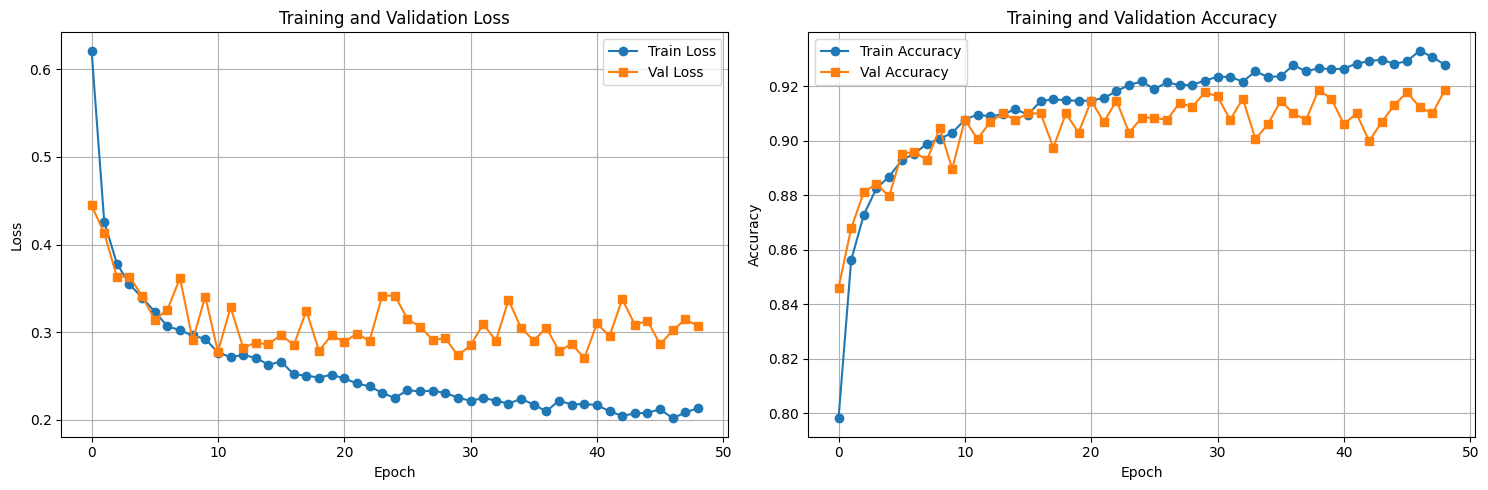

Training history saved to: training_history.png

Final Validation Results (Best Model):
  Loss: 0.2866
  Accuracy: 0.9187 (91.87%)

--------------------------------------------------------------------------------
STEP 5: BATCH PREDICTION EXAMPLES
--------------------------------------------------------------------------------

BATCH PREDICTION RESULTS

Sample 1:
  True Class:      Unknown/Transition
  Predicted Class: Unknown/Transition
  Correct:         ✓ Yes

  Top 3 Probabilities:
    Unknown/Transition  : 0.9984 ←
    Uttarabodhi         : 0.0011 
    Ksepana             : 0.0003 

Sample 2:
  True Class:      Uttarabodhi
  Predicted Class: Uttarabodhi
  Correct:         ✓ Yes

  Top 3 Probabilities:
    Uttarabodhi         : 0.9987 ←
    Unknown/Transition  : 0.0010 
    Namaskara           : 0.0002 

Sample 3:
  True Class:      Unknown/Transition
  Predicted Class: Unknown/Transition
  Correct:         ✓ Yes

  Top 3 Probabilities:
    Unknown/Transition  : 0.9976 ←
    Ksepana

C:\Users\drodm\AppData\Local\Temp\ipykernel_29340\2403418275.py:668: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


✓ All attention heads saved: all_attention_heads.png

PIPELINE COMPLETED SUCCESSFULLY!

Saved Files:
  • best_mudra_transformer.pth - Trained model checkpoint
  • mudra_label_encoder.joblib - Label encoder
  • mudra_scaler.joblib - Feature scaler
  • training_history.png - Training metrics
  • attention_matrix_*.png - Attention visualizations
  • all_attention_heads.png - Complete attention overview

Model Configuration Saved:
  input_dim: 12
  d_model: 128
  nhead: 8
  num_encoder_layers: 4
  dim_feedforward: 512
  num_classes: 13
  dropout: 0.2
  seq_length: 10
  stride: 5
  use_augmentation: True
  noise_std: 0.08
  num_augmented_copies: 4


In [3]:
# ============================================================================
# SECTION 1: IMPORTS AND SETUP
# ============================================================================

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import joblib

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ============================================================================
# SECTION 2: DATA PREPROCESSING
# ============================================================================

class MudraDataset(Dataset):
    """Dataset for hand tracking data with sequential samples and augmentation support."""
    
    def __init__(self, features, labels=None, seq_length=10, stride=1, augment=False, 
                 noise_std=0.05, num_augmented_copies=2):
        """
        Parameters:
        -----------
        features : np.ndarray
            Input features
        labels : np.ndarray, optional
            Labels
        seq_length : int
            Length of sequences
        stride : int
            Stride for sequence creation
        augment : bool
            Whether to apply data augmentation
        noise_std : float
            Standard deviation of Gaussian noise for augmentation
        num_augmented_copies : int
            Number of augmented copies to create per original sample
        """
        self.features = features
        self.labels = labels
        self.seq_length = seq_length
        self.stride = stride
        self.augment = augment
        self.noise_std = noise_std
        self.num_augmented_copies = num_augmented_copies
        self.indices = self._create_indices()
        
    def _create_indices(self):
        """Create valid sequence indices."""
        indices = []
        for i in range(0, len(self.features) - self.seq_length + 1, self.stride):
            indices.append(i)
        return indices
    
    def _apply_gaussian_noise(self, sequence):
        """Apply Gaussian noise to a sequence."""
        noise = np.random.normal(0, self.noise_std, sequence.shape)
        return sequence + noise
    
    def __len__(self):
        if self.augment:
            return len(self.indices) * (1 + self.num_augmented_copies)
        return len(self.indices)
    
    def __getitem__(self, idx):
        # Determine if this is an original or augmented sample
        if self.augment:
            original_idx = idx // (1 + self.num_augmented_copies)
            augment_idx = idx % (1 + self.num_augmented_copies)
            is_augmented = augment_idx > 0
        else:
            original_idx = idx
            is_augmented = False
        
        start_idx = self.indices[original_idx]
        end_idx = start_idx + self.seq_length
        
        seq_features = self.features[start_idx:end_idx].copy()
        
        # Apply augmentation if needed
        if is_augmented:
            seq_features = self._apply_gaussian_noise(seq_features)
        
        if self.labels is not None:
            seq_label = self.labels[end_idx - 1]
            return torch.FloatTensor(seq_features), torch.LongTensor([seq_label])
        
        return torch.FloatTensor(seq_features)

def load_and_preprocess_data(file_path, seq_length=30, stride=5, test_size=0.2, random_state=42,
                             use_augmentation=True, noise_std=0.05, num_augmented_copies=2):
    """
    Load and preprocess hand tracking data with optional augmentation.
    
    Parameters:
    -----------
    file_path : str
        Path to the CSV file
    seq_length : int
        Length of sequences
    stride : int
        Stride for sequence creation
    test_size : float
        Proportion of data for validation
    random_state : int
        Random seed
    use_augmentation : bool
        Whether to use data augmentation on training set
    noise_std : float
        Standard deviation of Gaussian noise for augmentation
    num_augmented_copies : int
        Number of augmented copies per original sample
    """
    
    # Load data
    df = pd.read_csv(file_path)
    
    # Select only the specified columns
    columns_to_use = [
        'Time', 'R_PositionX', 'R_PositionY', 'R_PositionZ',
        'R_RotationX', 'R_RotationY', 'R_RotationZ', 'R_RotationW',
        'R_CurlIndex', 'R_CurlMiddle', 'R_CurlRing', 'R_CurlPinky', 'R_CurlThumb',
        'Mudra'
    ]
    
    # Filter to keep only specified columns (if they exist)
    available_columns = [col for col in columns_to_use if col in df.columns]
    df = df[available_columns]
    
    print(f"\nColumns used for training: {[col for col in available_columns if col not in ['Time', 'Mudra']]}")
    
    # Fill missing values
    df = df.fillna(method='ffill')
    df = df.fillna(method='bfill')
    
    # Separate features and labels
    feature_columns = [col for col in df.columns if col not in ['Time', 'Mudra']]
    features = df[feature_columns].values
    labels = df['Mudra'].values
    
    print(f"Feature shape: {features.shape}")
    print(f"Number of features: {len(feature_columns)}")
    
    # Normalize features
    scaler = StandardScaler()
    features = scaler.fit_transform(features)
    joblib.dump(scaler, 'mudra_scaler.joblib')
    
    # Encode labels
    label_encoder = LabelEncoder()
    encoded_labels = label_encoder.fit_transform(labels)
    joblib.dump(label_encoder, 'mudra_label_encoder.joblib')
    
    print(f"Label encoder saved with {len(label_encoder.classes_)} classes: {label_encoder.classes_}")
    
    # Train-test split
    X_train, X_val, y_train, y_val = train_test_split(
        features, encoded_labels, test_size=test_size, random_state=random_state, stratify=encoded_labels
    )
    
    print(f"Training samples: {len(X_train)}, Validation samples: {len(X_val)}")
    
    # Create datasets with augmentation for training only
    train_dataset = MudraDataset(
        X_train, y_train, 
        seq_length=seq_length, 
        stride=stride,
        augment=use_augmentation,
        noise_std=noise_std,
        num_augmented_copies=num_augmented_copies
    )
    
    val_dataset = MudraDataset(
        X_val, y_val, 
        seq_length=seq_length, 
        stride=stride,
        augment=False  # No augmentation for validation
    )
    
    original_train_sequences = len(train_dataset.indices)
    augmented_train_sequences = len(train_dataset)
    
    print(f"\n{'='*80}")
    print("DATASET STATISTICS")
    print(f"{'='*80}")
    print(f"Training sequences (original): {original_train_sequences}")
    if use_augmentation:
        print(f"Training sequences (with augmentation): {augmented_train_sequences}")
        print(f"  → Augmentation factor: {num_augmented_copies + 1}x")
        print(f"  → Gaussian noise std: {noise_std}")
        print(f"  → Added sequences: {augmented_train_sequences - original_train_sequences}")
    print(f"Validation sequences: {len(val_dataset)}")
    print(f"{'='*80}\n")
    
    # Create dataloaders
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
    
    input_dim = features.shape[1]
    num_classes = len(label_encoder.classes_)
    
    return train_loader, val_loader, input_dim, num_classes, label_encoder, scaler

# ============================================================================
# SECTION 3: MODEL ARCHITECTURE
# ============================================================================

class PositionalEncoding(nn.Module):
    """Positional encoding for transformer."""
    
    def __init__(self, d_model, max_seq_length=5000):
        super(PositionalEncoding, self).__init__()
        
        pe = torch.zeros(max_seq_length, d_model)
        position = torch.arange(0, max_seq_length, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        
        self.register_buffer('pe', pe)
        
    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

class CustomTransformerEncoderLayer(nn.TransformerEncoderLayer):
    """Custom transformer encoder layer that returns attention weights."""
    
    def forward(self, src, src_mask=None, src_key_padding_mask=None):
        src2, attn_weights = self._sa_block(src, src_mask, src_key_padding_mask)
        src = src + self.dropout1(src2)
        src = self.norm1(src)
        
        src2 = self._ff_block(src)
        src = src + self.dropout2(src2)
        src = self.norm2(src)
        
        return src, attn_weights
    
    def _sa_block(self, x, attn_mask, key_padding_mask):
        x2, attn_weights = self.self_attn(
            x, x, x,
            attn_mask=attn_mask,
            key_padding_mask=key_padding_mask,
            need_weights=True
        )
        return x2, attn_weights

class CustomTransformerEncoder(nn.Module):
    """Custom transformer encoder that returns attention weights."""
    
    def __init__(self, encoder_layer, num_layers):
        super(CustomTransformerEncoder, self).__init__()
        self.layers = nn.ModuleList([encoder_layer for _ in range(num_layers)])
        self.num_layers = num_layers
    
    def forward(self, src, mask=None, src_key_padding_mask=None):
        output = src
        attention_weights = []
        
        for layer in self.layers:
            output, attn_weights = layer(output, src_mask=mask, src_key_padding_mask=src_key_padding_mask)
            attention_weights.append(attn_weights)
        
        return output, attention_weights

class MudraTransformer(nn.Module):
    """Transformer model for mudra classification."""
    
    def __init__(self, input_dim, d_model, nhead, num_encoder_layers, dim_feedforward, num_classes, dropout=0.1):
        super(MudraTransformer, self).__init__()
        
        self.embedding = nn.Linear(input_dim, d_model)
        self.positional_encoding = PositionalEncoding(d_model)
        
        encoder_layer = CustomTransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=False
        )
        self.transformer_encoder = CustomTransformerEncoder(encoder_layer, num_layers=num_encoder_layers)
        
        self.classifier = nn.Linear(d_model, num_classes)
        self.d_model = d_model
        self.dropout = nn.Dropout(dropout)
        self.nhead = nhead
        self.num_encoder_layers = num_encoder_layers
        
    def forward(self, x, src_mask=None, return_attention=False):
        # x: [batch_size, seq_len, input_dim]
        x = self.embedding(x) * math.sqrt(self.d_model)
        x = self.positional_encoding(x)
        x = self.dropout(x)
        
        # Transform to [seq_len, batch_size, d_model]
        x = x.permute(1, 0, 2)
        
        output, attention_weights = self.transformer_encoder(x, src_mask)
        
        # Transform back to [batch_size, seq_len, d_model]
        output = output.permute(1, 0, 2)
        
        # Use last element for classification
        output_last = output[:, -1, :]
        logits = self.classifier(output_last)
        
        if return_attention:
            return logits, attention_weights
        return logits

# ============================================================================
# SECTION 4: TRAINING
# ============================================================================

# ============================================================================
# SECTION 4: TRAINING (COMPLETE WITH HELPER FUNCTIONS)
# ============================================================================

def train_epoch(model, train_loader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for features, labels in train_loader:
        features, labels = features.to(device), labels.squeeze().to(device)
        
        # Check for NaN values
        if torch.isnan(features).any():
            print("Warning: NaN values found in features, skipping batch")
            continue
            
        optimizer.zero_grad()
        outputs = model(features)
        loss = criterion(outputs, labels)
        
        # Check for NaN loss
        if torch.isnan(loss).any():
            print("Warning: NaN loss detected, skipping batch")
            continue
        
        loss.backward()
        
        # Gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        running_loss += loss.item() * features.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    if total == 0:
        return float('nan'), float('nan')
        
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def validate(model, val_loader, criterion, device):
    """Validate the model."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for features, labels in val_loader:
            features, labels = features.to(device), labels.squeeze().to(device)
            
            outputs = model(features)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * features.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def save_model_checkpoint(model, optimizer, epoch, val_acc, model_config, filepath='best_mudra_transformer.pth'):
    """
    Save complete model checkpoint with all necessary information.
    
    Parameters:
    -----------
    model : nn.Module
        The model to save
    optimizer : torch.optim.Optimizer
        The optimizer
    epoch : int
        Current epoch number
    val_acc : float
        Validation accuracy
    model_config : dict
        Dictionary containing model configuration
    filepath : str
        Path to save the checkpoint
    """
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'val_acc': val_acc,
        'model_config': model_config
    }
    torch.save(checkpoint, filepath)
    print(f"  ✓ Checkpoint saved to: {filepath}")

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, device, 
                model_config, patience=10):
    """
    Train the model with early stopping and proper checkpointing.
    
    Parameters:
    -----------
    model : nn.Module
        The model to train
    train_loader : DataLoader
        Training data loader
    val_loader : DataLoader
        Validation data loader
    criterion : nn.Module
        Loss function
    optimizer : torch.optim.Optimizer
        Optimizer
    num_epochs : int
        Maximum number of epochs
    device : torch.device
        Device to train on
    model_config : dict
        Model configuration dictionary
    patience : int
        Early stopping patience
    """
    best_val_acc = 0.0
    patience_counter = 0
    
    train_losses = []
    train_accs = []
    val_losses = []
    val_accs = []
    
    print(f"\nStarting training for up to {num_epochs} epochs...")
    print(f"Early stopping patience: {patience}")
    print("-" * 80)
    
    for epoch in range(num_epochs):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate(model, val_loader, criterion, device)
        
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        
        print(f'Epoch {epoch+1}/{num_epochs}:')
        print(f'  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} ({train_acc*100:.2f}%)')
        print(f'  Val Loss:   {val_loss:.4f}, Val Acc:   {val_acc:.4f} ({val_acc*100:.2f}%)')
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            
            # Save complete checkpoint
            save_model_checkpoint(
                model=model,
                optimizer=optimizer,
                epoch=epoch,
                val_acc=val_acc,
                model_config=model_config,
                filepath='best_mudra_transformer.pth'
            )
        else:
            patience_counter += 1
            print(f'  No improvement. Patience: {patience_counter}/{patience}')
            
            if patience_counter >= patience:
                print(f'\n⚠ Early stopping triggered after {epoch+1} epochs!')
                print(f'Best validation accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)')
                break
    
    # Load best model
    print(f"\nLoading best model (Val Acc: {best_val_acc:.4f})...")
    checkpoint = torch.load('best_mudra_transformer.pth', map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    
    return model, {
        'train_losses': train_losses,
        'train_accs': train_accs,
        'val_losses': val_losses,
        'val_accs': val_accs,
        'best_val_acc': best_val_acc,
        'best_epoch': checkpoint['epoch']
    }


# ============================================================================
# SECTION 5: VISUALIZATION - TRAINING METRICS
# ============================================================================

def plot_training_history(history):
    """Plot training and validation metrics."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Plot loss
    ax1.plot(history['train_losses'], label='Train Loss', marker='o')
    ax1.plot(history['val_losses'], label='Val Loss', marker='s')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training and Validation Loss')
    ax1.legend()
    ax1.grid(True)
    
    # Plot accuracy
    ax2.plot(history['train_accs'], label='Train Accuracy', marker='o')
    ax2.plot(history['val_accs'], label='Val Accuracy', marker='s')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_title('Training and Validation Accuracy')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Training history saved to: training_history.png")

# ============================================================================
# SECTION 6: VISUALIZATION - ATTENTION PATTERNS
# ============================================================================

def plot_attention_matrix(attention_weights, seq_length, layer_idx=0, head_idx=0, sample_idx=0,
                         predicted_class=None, true_class=None):
    """Plot attention matrix for a specific layer and head."""
    
    plt.figure(figsize=(10, 8))
    
    # Extract attention matrix
    if isinstance(attention_weights[layer_idx], torch.Tensor):
        attn_shape = attention_weights[layer_idx].shape
        
        if len(attn_shape) == 4:
            attn_matrix = attention_weights[layer_idx][sample_idx, head_idx].cpu().numpy()
        elif len(attn_shape) == 3:
            attn_matrix = attention_weights[layer_idx][sample_idx].cpu().numpy()
        else:
            attn_matrix = np.ones((seq_length, seq_length)) / seq_length
    else:
        try:
            attn_matrix = attention_weights[layer_idx][0][sample_idx, head_idx].cpu().numpy()
        except (TypeError, IndexError):
            attn_matrix = np.ones((seq_length, seq_length)) / seq_length
    
    # Create heatmap
    sns.heatmap(attn_matrix, annot=False, cmap='viridis', cbar_kws={'label': 'Attention Weight'})
    
    # Add title with prediction info
    title = f"Attention Matrix - Layer {layer_idx+1}, Head {head_idx+1}"
    if predicted_class and true_class:
        match_status = "✓" if predicted_class == true_class else "✗"
        title += f"\nPredicted: {predicted_class} | Actual: {true_class} {match_status}"
    
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel("Target Position")
    plt.ylabel("Source Position")
    plt.tight_layout()
    
    save_path = f'attention_matrix_layer{layer_idx+1}_head{head_idx+1}.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()
    
    return save_path

def plot_all_attention_heads(attention_weights, seq_length, num_layers, num_heads, sample_idx=0,
                            predicted_class=None, true_class=None):
    """Plot attention matrices for all heads and layers."""
    
    fig_width = max(12, num_heads * 2.5)
    fig_height = max(8, num_layers * 2.5)
    
    fig, axes = plt.subplots(num_layers, num_heads, figsize=(fig_width, fig_height), squeeze=False)
    
    # Add super title
    if predicted_class and true_class:
        match_status = "Correct ✓" if predicted_class == true_class else "Incorrect ✗"
        plt.suptitle(f"Attention Patterns - All Layers and Heads\n" + 
                    f"Prediction: {predicted_class} | Actual: {true_class} ({match_status})",
                    fontsize=16, fontweight='bold', y=0.98)
    else:
        plt.suptitle("Attention Patterns - All Layers and Heads", 
                    fontsize=16, fontweight='bold', y=0.98)
    
    # Find global max for consistent coloring
    max_value = 0
    matrices = []
    
    for layer in range(num_layers):
        layer_matrices = []
        for head in range(num_heads):
            if isinstance(attention_weights[layer], torch.Tensor):
                attn_shape = attention_weights[layer].shape
                
                if len(attn_shape) == 4:
                    attn_matrix = attention_weights[layer][sample_idx, head].cpu().numpy()
                elif len(attn_shape) == 3:
                    attn_matrix = attention_weights[layer][sample_idx].cpu().numpy()
                else:
                    attn_matrix = np.ones((seq_length, seq_length)) / seq_length
            else:
                try:
                    attn_matrix = attention_weights[layer][0][sample_idx, head].cpu().numpy()
                except (TypeError, IndexError):
                    attn_matrix = np.ones((seq_length, seq_length)) / seq_length
            
            layer_matrices.append(attn_matrix)
            max_value = max(max_value, attn_matrix.max())
        
        matrices.append(layer_matrices)
    
    # Plot all matrices
    for layer in range(num_layers):
        for head in range(num_heads):
            ax = axes[layer, head]
            attn_matrix = matrices[layer][head]
            
            sns.heatmap(attn_matrix, annot=False, cmap='YlGnBu', ax=ax, 
                       cbar=False, vmin=0, vmax=max_value)
            
            ax.set_title(f"L{layer+1}H{head+1}", fontsize=10)
            
            if layer == num_layers - 1:
                ax.set_xticks([0, seq_length-1])
                ax.set_xticklabels(['t0', f't{seq_length-1}'], fontsize=8)
            else:
                ax.set_xticks([])
            
            if head == 0:
                ax.set_yticks([0, seq_length-1])
                ax.set_yticklabels(['t0', f't{seq_length-1}'], fontsize=8)
            else:
                ax.set_yticks([])
    
    # Add colorbar
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    sm = plt.cm.ScalarMappable(cmap='YlGnBu', norm=plt.Normalize(0, max_value))
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.set_label('Attention Weight')
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.92, right=0.9, wspace=0.1, hspace=0.2)
    
    save_path = 'all_attention_heads.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()
    
    return save_path

# ============================================================================
# SECTION 7: BATCH PREDICTION
# ============================================================================

def predict_batch(model, data_loader, label_encoder, device, num_samples=5):
    """Make predictions on a batch of samples."""
    
    model.eval()
    results = []
    
    with torch.no_grad():
        for features, labels in data_loader:
            features = features.to(device)
            labels = labels.squeeze()
            
            # Get predictions with attention
            outputs, attention_weights = model(features, return_attention=True)
            probabilities = torch.nn.functional.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)
            
            # Convert to class names
            predicted_classes = label_encoder.inverse_transform(predicted.cpu().numpy())
            true_classes = label_encoder.inverse_transform(labels.numpy())
            
            # Store results for each sample in batch
            for i in range(min(len(predicted_classes), num_samples)):
                results.append({
                    'sample_idx': i,
                    'true_class': true_classes[i],
                    'predicted_class': predicted_classes[i],
                    'correct': predicted_classes[i] == true_classes[i],
                    'probabilities': probabilities[i].cpu().numpy(),
                    'attention_weights': attention_weights,
                    'features': features[i]
                })
            
            if len(results) >= num_samples:
                break
    
    return results

def print_batch_predictions(results, label_encoder):
    """Print batch prediction results in a formatted table."""
    
    print("\n" + "="*80)
    print("BATCH PREDICTION RESULTS")
    print("="*80)
    
    for i, result in enumerate(results):
        print(f"\nSample {i+1}:")
        print(f"  True Class:      {result['true_class']}")
        print(f"  Predicted Class: {result['predicted_class']}")
        print(f"  Correct:         {'✓ Yes' if result['correct'] else '✗ No'}")
        print(f"\n  Top 3 Probabilities:")
        
        # Get top 3 predictions
        probs = result['probabilities']
        top_3_idx = np.argsort(probs)[-3:][::-1]
        
        for idx in top_3_idx:
            class_name = label_encoder.inverse_transform([idx])[0]
            print(f"    {class_name:20s}: {probs[idx]:.4f} {'←' if idx == label_encoder.transform([result['predicted_class']])[0] else ''}")
    
    # Calculate accuracy
    correct = sum(1 for r in results if r['correct'])
    accuracy = correct / len(results) * 100
    print(f"\n" + "="*80)
    print(f"Batch Accuracy: {correct}/{len(results)} ({accuracy:.2f}%)")
    print("="*80 + "\n")

# ============================================================================
# SECTION 8: MAIN EXECUTION
# ============================================================================

def main(file_path, use_augmentation=True, noise_std=0.05, num_augmented_copies=2):
    """
    Main training and evaluation pipeline with optional data augmentation.
    
    Parameters:
    -----------
    file_path : str
        Path to the CSV data file
    use_augmentation : bool
        Whether to use Gaussian noise augmentation
    noise_std : float
        Standard deviation of Gaussian noise (typical range: 0.01-0.1)
    num_augmented_copies : int
        Number of augmented copies per original sample (1-5 recommended)
    """
    
    print("="*80)
    print("MUDRA GESTURE RECOGNITION WITH TRANSFORMER")
    print("="*80)
    
    # Hyperparameters
    seq_length = 10
    stride = 5
    d_model = 128
    nhead = 8
    num_encoder_layers = 4
    dim_feedforward = 512
    dropout = 0.2
    learning_rate = 0.001
    num_epochs = 50
    patience = 10
    
    print("\nHyperparameters:")
    print(f"  Sequence Length: {seq_length}")
    print(f"  Model Dimension: {d_model}")
    print(f"  Attention Heads: {nhead}")
    print(f"  Encoder Layers: {num_encoder_layers}")
    print(f"  Learning Rate: {learning_rate}")
    print(f"\nData Augmentation:")
    print(f"  Enabled: {use_augmentation}")
    if use_augmentation:
        print(f"  Gaussian Noise Std: {noise_std}")
        print(f"  Augmented Copies: {num_augmented_copies}")
        print(f"  Total Augmentation Factor: {num_augmented_copies + 1}x")
    
    # Load and preprocess data
    print("\n" + "-"*80)
    print("STEP 1: DATA LOADING AND PREPROCESSING")
    print("-"*80)
    
    train_loader, val_loader, input_dim, num_classes, label_encoder, scaler = load_and_preprocess_data(
        file_path, 
        seq_length=seq_length, 
        stride=stride,
        use_augmentation=use_augmentation,
        noise_std=noise_std,
        num_augmented_copies=num_augmented_copies
    )
    
    print(f"\nData loaded successfully:")
    print(f"  Input Dimension: {input_dim}")
    print(f"  Number of Classes: {num_classes}")
    print(f"  Classes: {', '.join(label_encoder.classes_)}")
    
    # Initialize model
    print("\n" + "-"*80)
    print("STEP 2: MODEL INITIALIZATION")
    print("-"*80)
    
    model = MudraTransformer(
        input_dim=input_dim,
        d_model=d_model,
        nhead=nhead,
        num_encoder_layers=num_encoder_layers,
        dim_feedforward=dim_feedforward,
        num_classes=num_classes,
        dropout=dropout
    ).to(device)
    
    total_params = sum(p.numel() for p in model.parameters())
    print(f"\nModel initialized:")
    print(f"  Total Parameters: {total_params:,}")
    
    # Create model configuration dictionary for saving
    model_config = {
        'input_dim': input_dim,
        'd_model': d_model,
        'nhead': nhead,
        'num_encoder_layers': num_encoder_layers,
        'dim_feedforward': dim_feedforward,
        'num_classes': num_classes,
        'dropout': dropout,
        'seq_length': seq_length,
        'stride': stride,
        'use_augmentation': use_augmentation,
        'noise_std': noise_std if use_augmentation else None,
        'num_augmented_copies': num_augmented_copies if use_augmentation else None
    }
    
    # Define loss and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    # Train model
    print("\n" + "-"*80)
    print("STEP 3: MODEL TRAINING")
    print("-"*80)
    
    model, history = train_model(
        model, train_loader, val_loader, criterion, optimizer, 
        num_epochs, device, model_config, patience=patience
    )
    
    print("\n✓ Training completed!")
    print(f"Best validation accuracy: {history['best_val_acc']:.4f} ({history['best_val_acc']*100:.2f}%)")
    print(f"Best epoch: {history['best_epoch'] + 1}")
    
    # Plot training history
    print("\n" + "-"*80)
    print("STEP 4: TRAINING VISUALIZATION")
    print("-"*80 + "\n")
    
    plot_training_history(history)
    
    # Final validation
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    print(f"\nFinal Validation Results (Best Model):")
    print(f"  Loss: {val_loss:.4f}")
    print(f"  Accuracy: {val_acc:.4f} ({val_acc*100:.2f}%)")
    
    # Batch predictions
    print("\n" + "-"*80)
    print("STEP 5: BATCH PREDICTION EXAMPLES")
    print("-"*80)
    
    results = predict_batch(model, val_loader, label_encoder, device, num_samples=10)
    print_batch_predictions(results, label_encoder)
    
    # Visualize attention for first sample
    print("\n" + "-"*80)
    print("STEP 6: ATTENTION VISUALIZATION")
    print("-"*80 + "\n")
    
    sample = results[0]
    
    # Single attention matrix
    attn_file = plot_attention_matrix(
        sample['attention_weights'],
        seq_length,
        layer_idx=num_encoder_layers-1,
        head_idx=0,
        sample_idx=0,
        predicted_class=sample['predicted_class'],
        true_class=sample['true_class']
    )
    print(f"✓ Single attention matrix saved: {attn_file}")
    
    # All attention heads
    all_heads_file = plot_all_attention_heads(
        sample['attention_weights'],
        seq_length,
        num_encoder_layers,
        nhead,
        sample_idx=0,
        predicted_class=sample['predicted_class'],
        true_class=sample['true_class']
    )
    print(f"✓ All attention heads saved: {all_heads_file}")
    
    print("\n" + "="*80)
    print("PIPELINE COMPLETED SUCCESSFULLY!")
    print("="*80)
    
    print("\nSaved Files:")
    print("  • best_mudra_transformer.pth - Trained model checkpoint")
    print("  • mudra_label_encoder.joblib - Label encoder")
    print("  • mudra_scaler.joblib - Feature scaler")
    print("  • training_history.png - Training metrics")
    print("  • attention_matrix_*.png - Attention visualizations")
    print("  • all_attention_heads.png - Complete attention overview")
    
    print("\nModel Configuration Saved:")
    for key, value in model_config.items():
        print(f"  {key}: {value}")
    
    return model, history, label_encoder, scaler

# ============================================================================
# SECTION 9: UPDATED MODEL LOADING FUNCTION
# ============================================================================

def load_trained_model(model_path='best_mudra_transformer.pth', 
                       label_encoder_path='mudra_label_encoder.joblib',
                       scaler_path='mudra_scaler.joblib'):
    """
    Load a trained model properly from checkpoint.
    
    Parameters:
    -----------
    model_path : str
        Path to the saved model checkpoint
    label_encoder_path : str
        Path to the saved label encoder
    scaler_path : str
        Path to the saved scaler
    
    Returns:
    --------
    tuple : (model, label_encoder, scaler, checkpoint_info)
    """
    
    print("Loading trained model from checkpoint...")
    
    # Load label encoder and scaler
    label_encoder = joblib.load(label_encoder_path)
    scaler = joblib.load(scaler_path)
    
    # Load checkpoint
    checkpoint = torch.load(model_path, map_location=device)
    
    # Get model configuration
    if 'model_config' in checkpoint:
        config = checkpoint['model_config']
        print("✓ Model configuration found in checkpoint")
    else:
        # Fallback to default configuration
        print("⚠ Model config not found in checkpoint, using default configuration")
        config = {
            'input_dim': 12,
            'd_model': 128,
            'nhead': 8,
            'num_encoder_layers': 4,
            'dim_feedforward': 512,
            'num_classes': len(label_encoder.classes_),
            'dropout': 0.2
        }
    
    # Initialize model with saved configuration
    model = MudraTransformer(
        input_dim=config['input_dim'],
        d_model=config['d_model'],
        nhead=config['nhead'],
        num_encoder_layers=config['num_encoder_layers'],
        dim_feedforward=config['dim_feedforward'],
        num_classes=config['num_classes'],
        dropout=config['dropout']
    ).to(device)
    
    # Load model state
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    
    # Get checkpoint info
    checkpoint_info = {
        'epoch': checkpoint.get('epoch', 'unknown'),
        'val_acc': checkpoint.get('val_acc', 'unknown'),
        'config': config
    }
    
    print(f"\n✓ Model loaded successfully from checkpoint")
    print(f"  Epoch: {checkpoint_info['epoch']}")
    if isinstance(checkpoint_info['val_acc'], float):
        print(f"  Validation Accuracy: {checkpoint_info['val_acc']:.4f} ({checkpoint_info['val_acc']*100:.2f}%)")
    else:
        print(f"  Validation Accuracy: {checkpoint_info['val_acc']}")
    print(f"  Input Dimension: {config['input_dim']}")
    print(f"  Number of Classes: {config['num_classes']}")
    print(f"  Model Parameters: {sum(p.numel() for p in model.parameters()):,}")
    
    return model, label_encoder, scaler, checkpoint_info

# ============================================================================
# EXECUTE MAIN
# ============================================================================

if __name__ == "__main__":
    # Replace with your actual file path
    file_path = r'C:\Users\drodm\OneDrive\Documents\GitHub\Mudras_hand_deteccion_classifier\Hand_classifier\Primeira_Leva_de_dados\combined_data_with_classification.csv'
    
    # Run with data augmentation
    # Recommended settings:
    # - noise_std: 0.03-0.07 for subtle augmentation, 0.1-0.15 for aggressive
    # - num_augmented_copies: 1-3 for 2x-4x dataset size
    
    model, history, label_encoder, scaler = main(
        file_path,
        use_augmentation=True,      # Enable augmentation
        noise_std=0.08,              # Gaussian noise std deviation
        num_augmented_copies=4       # Create 2 augmented copies per sample (3x total)
    )

In [ ]:
# # Conservative (2x dataset, subtle noise)
# main(file_path, use_augmentation=True, noise_std=0.03, num_augmented_copies=1)

# # Moderate (3x dataset, moderate noise) - RECOMMENDED
# main(file_path, use_augmentation=True, noise_std=0.05, num_augmented_copies=2)

# # Aggressive (5x dataset, strong noise)
# main(file_path, use_augmentation=True, noise_std=0.08, num_augmented_copies=4)

# # Disable augmentation
# main(file_path, use_augmentation=False)

MUDRA GESTURE RECOGNITION WITH TRANSFORMER

Hyperparameters:
  Sequence Length: 10
  Model Dimension: 128
  Attention Heads: 8
  Encoder Layers: 4
  Learning Rate: 0.001

Data Augmentation:
  Enabled: True
  Gaussian Noise Std: 0.05
  Augmented Copies: 2
  Total Augmentation Factor: 3x

--------------------------------------------------------------------------------
STEP 1: DATA LOADING AND PREPROCESSING
--------------------------------------------------------------------------------

Columns used for training: ['R_PositionX', 'R_PositionY', 'R_PositionZ', 'R_RotationX', 'R_RotationY', 'R_RotationZ', 'R_RotationW', 'R_CurlIndex', 'R_CurlMiddle', 'R_CurlRing', 'R_CurlPinky', 'R_CurlThumb']


C:\Users\drodm\AppData\Local\Temp\ipykernel_29340\2403418275.py:143: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')
C:\Users\drodm\AppData\Local\Temp\ipykernel_29340\2403418275.py:144: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill')


Feature shape: (32001, 12)
Number of features: 12
Label encoder saved with 13 classes: ['Abhaya' 'Bhumisparsa' 'Dharmachakra' 'Dhyana' 'Jnana' 'Karana' 'Ksepana'
 'Namaskara' 'Tarjani' 'Unknown/Transition' 'Uttarabodhi' 'Varada'
 'Vitarka']
Training samples: 25600, Validation samples: 6401

DATASET STATISTICS
Training sequences (original): 5119
Training sequences (with augmentation): 15357
  → Augmentation factor: 3x
  → Gaussian noise std: 0.05
  → Added sequences: 10238
Validation sequences: 1279


Data loaded successfully:
  Input Dimension: 12
  Number of Classes: 13
  Classes: Abhaya, Bhumisparsa, Dharmachakra, Dhyana, Jnana, Karana, Ksepana, Namaskara, Tarjani, Unknown/Transition, Uttarabodhi, Varada, Vitarka

--------------------------------------------------------------------------------
STEP 2: MODEL INITIALIZATION
--------------------------------------------------------------------------------

Model initialized:
  Total Parameters: 201,613

----------------------------------

C:\Users\drodm\AppData\Local\Temp\ipykernel_29340\2403418275.py:502: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load('best_mudra_transformer.pth', map_

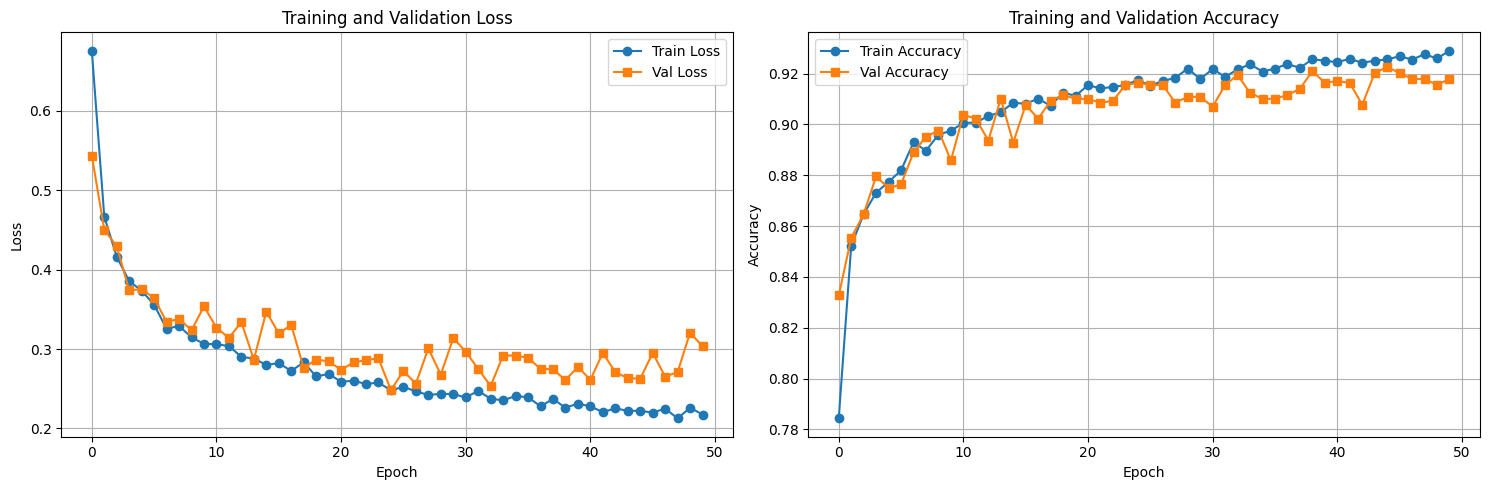

Training history saved to: training_history.png

Final Validation Results (Best Model):
  Loss: 0.2625
  Accuracy: 0.9226 (92.26%)

--------------------------------------------------------------------------------
STEP 5: BATCH PREDICTION EXAMPLES
--------------------------------------------------------------------------------

BATCH PREDICTION RESULTS

Sample 1:
  True Class:      Unknown/Transition
  Predicted Class: Unknown/Transition
  Correct:         ✓ Yes

  Top 3 Probabilities:
    Unknown/Transition  : 0.9989 ←
    Uttarabodhi         : 0.0005 
    Dhyana              : 0.0001 

Sample 2:
  True Class:      Uttarabodhi
  Predicted Class: Uttarabodhi
  Correct:         ✓ Yes

  Top 3 Probabilities:
    Uttarabodhi         : 0.9981 ←
    Unknown/Transition  : 0.0014 
    Namaskara           : 0.0005 

Sample 3:
  True Class:      Unknown/Transition
  Predicted Class: Unknown/Transition
  Correct:         ✓ Yes

  Top 3 Probabilities:
    Unknown/Transition  : 0.9987 ←
    Uttarab

C:\Users\drodm\AppData\Local\Temp\ipykernel_29340\2403418275.py:668: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


✓ All attention heads saved: all_attention_heads.png

--------------------------------------------------------------------------------
STEP 7: CLASS-WISE ATTENTION ANALYSIS
--------------------------------------------------------------------------------

CLASS-WISE ATTENTION PATTERN ANALYSIS

[1/4] Collecting samples from each class...

--------------------------------------------------------------------------------
  ✓ Abhaya              : 3/3 samples
  ✓ Bhumisparsa         : 3/3 samples
  ✓ Dharmachakra        : 3/3 samples
  ✓ Dhyana              : 3/3 samples
  ✓ Jnana               : 3/3 samples
  ✓ Karana              : 3/3 samples
  ✓ Ksepana             : 3/3 samples
  ✓ Namaskara           : 3/3 samples
  ✓ Tarjani             : 3/3 samples
  ✓ Unknown/Transition  : 3/3 samples
  ✓ Uttarabodhi         : 3/3 samples
  ✓ Varada              : 3/3 samples
  ✓ Vitarka             : 3/3 samples

[2/4] Creating class comparison visualizations...


C:\Users\drodm\AppData\Local\Temp\ipykernel_29340\54568407.py:177: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


✓ Class comparison saved: class_attention_analysis\class_comparison_layer1_head1.png


...

C:\Users\drodm\AppData\Local\Temp\ipykernel_29340\54568407.py:177: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


✓ Class comparison saved: class_attention_analysis\class_comparison_layer4_head2.png

[3/4] Creating average attention visualizations...
✓ Average attention per class saved: class_attention_analysis\average_attention_layer1_head1.png
✓ Average attention per class saved: class_attention_analysis\average_attention_layer1_head2.png
✓ Average attention per class saved: class_attention_analysis\average_attention_layer2_head1.png
✓ Average attention per class saved: class_attention_analysis\average_attention_layer2_head2.png
✓ Average attention per class saved: class_attention_analysis\average_attention_layer3_head1.png
✓ Average attention per class saved: class_attention_analysis\average_attention_layer3_head2.png
✓ Average attention per class saved: class_attention_analysis\average_attention_layer4_head1.png
✓ Average attention per class saved: class_attention_analysis\average_attention_layer4_head2.png

[4/4] Analyzing attention statistics...
✓ Attention statistics saved: class_attention_

C:\Users\drodm\AppData\Local\Temp\ipykernel_29340\2403418275.py:143: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')
C:\Users\drodm\AppData\Local\Temp\ipykernel_29340\2403418275.py:144: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill')


Feature shape: (32001, 12)
Number of features: 12
Label encoder saved with 13 classes: ['Abhaya' 'Bhumisparsa' 'Dharmachakra' 'Dhyana' 'Jnana' 'Karana' 'Ksepana'
 'Namaskara' 'Tarjani' 'Unknown/Transition' 'Uttarabodhi' 'Varada'
 'Vitarka']
Training samples: 25600, Validation samples: 6401

DATASET STATISTICS
Training sequences (original): 5119
Training sequences (with augmentation): 25595
  → Augmentation factor: 5x
  → Gaussian noise std: 0.08
  → Added sequences: 20476
Validation sequences: 1279


Data loaded successfully:
  Input Dimension: 12
  Number of Classes: 13
  Classes: Abhaya, Bhumisparsa, Dharmachakra, Dhyana, Jnana, Karana, Ksepana, Namaskara, Tarjani, Unknown/Transition, Uttarabodhi, Varada, Vitarka

--------------------------------------------------------------------------------
STEP 2: MODEL INITIALIZATION
--------------------------------------------------------------------------------

Model initialized:
  Total Parameters: 201,613

----------------------------------

KeyboardInterrupt: 

In [ ]:
# ============================================================================
# SECTION 10: CLASS-WISE ATTENTION ANALYSIS
# ============================================================================

def collect_class_attention_samples(model, data_loader, label_encoder, device, samples_per_class=3):
    """
    Collect attention weights for samples from each class.
    
    Parameters:
    -----------
    model : nn.Module
        Trained model
    data_loader : DataLoader
        Data loader (validation set recommended)
    label_encoder : LabelEncoder
        Label encoder for class names
    device : torch.device
        Device to run on
    samples_per_class : int
        Number of samples to collect per class
    
    Returns:
    --------
    dict : Dictionary with class names as keys and list of sample data as values
    """
    model.eval()
    
    # Initialize storage for each class
    class_samples = {class_name: [] for class_name in label_encoder.classes_}
    class_counts = {class_name: 0 for class_name in label_encoder.classes_}
    
    print(f"\nCollecting {samples_per_class} samples per class...")
    print("-" * 80)
    
    with torch.no_grad():
        for features, labels in data_loader:
            features = features.to(device)
            labels = labels.squeeze()
            
            # Get predictions with attention
            outputs, attention_weights = model(features, return_attention=True)
            probabilities = torch.nn.functional.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)
            
            # Convert to class names
            true_classes = label_encoder.inverse_transform(labels.numpy())
            predicted_classes = label_encoder.inverse_transform(predicted.cpu().numpy())
            
            # Store correctly classified samples for each class
            for i in range(len(true_classes)):
                class_name = true_classes[i]
                
                # Only collect correctly classified samples
                if predicted_classes[i] == class_name and class_counts[class_name] < samples_per_class:
                    class_samples[class_name].append({
                        'features': features[i].cpu(),
                        'attention_weights': [attn[i:i+1].cpu() for attn in attention_weights],
                        'probabilities': probabilities[i].cpu().numpy(),
                        'predicted_class': predicted_classes[i],
                        'true_class': class_name
                    })
                    class_counts[class_name] += 1
            
            # Check if we have enough samples for all classes
            if all(count >= samples_per_class for count in class_counts.values()):
                break
    
    # Print collection summary
    for class_name, count in class_counts.items():
        status = "✓" if count >= samples_per_class else "⚠"
        print(f"  {status} {class_name:20s}: {count}/{samples_per_class} samples")
    
    return class_samples

def plot_class_attention_comparison(class_samples, label_encoder, seq_length, 
                                   layer_idx=0, head_idx=0, save_dir='class_attention_analysis'):
    """
    Create a comprehensive visualization comparing attention patterns across all classes.
    
    Parameters:
    -----------
    class_samples : dict
        Dictionary with class samples from collect_class_attention_samples()
    label_encoder : LabelEncoder
        Label encoder
    seq_length : int
        Sequence length
    layer_idx : int
        Which transformer layer to visualize
    head_idx : int
        Which attention head to visualize
    save_dir : str
        Directory to save visualizations
    """
    import os
    os.makedirs(save_dir, exist_ok=True)
    
    num_classes = len(label_encoder.classes_)
    samples_per_class = len(list(class_samples.values())[0])
    
    # Create figure with subplots for all classes and samples
    fig_width = max(20, samples_per_class * 4)
    fig_height = max(15, num_classes * 3)
    
    fig, axes = plt.subplots(num_classes, samples_per_class, 
                            figsize=(fig_width, fig_height), squeeze=False)
    
    plt.suptitle(f"Attention Patterns Across Classes - Layer {layer_idx+1}, Head {head_idx+1}",
                fontsize=20, fontweight='bold', y=0.995)
    
    # Find global max for consistent color scaling
    max_value = 0
    all_matrices = []
    
    for class_idx, class_name in enumerate(label_encoder.classes_):
        class_matrices = []
        for sample in class_samples[class_name]:
            attn_weights = sample['attention_weights'][layer_idx]
            
            if len(attn_weights.shape) == 4:
                attn_matrix = attn_weights[0, head_idx].numpy()
            elif len(attn_weights.shape) == 3:
                attn_matrix = attn_weights[0].numpy()
            else:
                attn_matrix = np.ones((seq_length, seq_length)) / seq_length
            
            class_matrices.append(attn_matrix)
            max_value = max(max_value, attn_matrix.max())
        
        all_matrices.append(class_matrices)
    
    # Plot all attention matrices
    for class_idx, class_name in enumerate(label_encoder.classes_):
        for sample_idx in range(samples_per_class):
            ax = axes[class_idx, sample_idx]
            
            if sample_idx < len(all_matrices[class_idx]):
                attn_matrix = all_matrices[class_idx][sample_idx]
                
                sns.heatmap(attn_matrix, annot=False, cmap='YlOrRd', ax=ax,
                           cbar=False, vmin=0, vmax=max_value, square=True)
                
                if sample_idx == 0:
                    ax.set_ylabel(f"{class_name}", fontsize=12, fontweight='bold')
                else:
                    ax.set_ylabel('')
                
                if class_idx == 0:
                    ax.set_title(f"Sample {sample_idx+1}", fontsize=11)
                else:
                    ax.set_title('')
                
                # Set tick labels only on edges
                if class_idx == num_classes - 1:
                    ax.set_xticks([0, seq_length-1])
                    ax.set_xticklabels(['0', f'{seq_length-1}'], fontsize=9)
                    ax.set_xlabel('Target Position', fontsize=9)
                else:
                    ax.set_xticks([])
                    ax.set_xlabel('')
                
                if sample_idx == 0:
                    ax.set_yticks([0, seq_length-1])
                    ax.set_yticklabels(['0', f'{seq_length-1}'], fontsize=9)
                else:
                    ax.set_yticks([])
            else:
                ax.axis('off')
    
    # Add colorbar
    cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
    sm = plt.cm.ScalarMappable(cmap='YlOrRd', norm=plt.Normalize(0, max_value))
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.set_label('Attention Weight', fontsize=12)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.97, right=0.91, wspace=0.1, hspace=0.15)
    
    save_path = os.path.join(save_dir, f'class_comparison_layer{layer_idx+1}_head{head_idx+1}.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()
    
    print(f"✓ Class comparison saved: {save_path}")
    return save_path

def plot_average_attention_per_class(class_samples, label_encoder, seq_length,
                                     layer_idx=0, head_idx=0, save_dir='class_attention_analysis'):
    """
    Plot average attention patterns for each class.
    
    Parameters:
    -----------
    class_samples : dict
        Dictionary with class samples
    label_encoder : LabelEncoder
        Label encoder
    seq_length : int
        Sequence length
    layer_idx : int
        Which transformer layer to visualize
    head_idx : int
        Which attention head to visualize
    save_dir : str
        Directory to save visualizations
    """
    import os
    os.makedirs(save_dir, exist_ok=True)
    
    num_classes = len(label_encoder.classes_)
    cols = min(4, num_classes)
    rows = (num_classes + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(cols*5, rows*4), squeeze=False)
    
    plt.suptitle(f"Average Attention Patterns Per Class - Layer {layer_idx+1}, Head {head_idx+1}",
                fontsize=16, fontweight='bold')
    
    # Calculate average attention for each class
    max_value = 0
    average_matrices = []
    
    for class_name in label_encoder.classes_:
        matrices = []
        for sample in class_samples[class_name]:
            attn_weights = sample['attention_weights'][layer_idx]
            
            if len(attn_weights.shape) == 4:
                attn_matrix = attn_weights[0, head_idx].numpy()
            elif len(attn_weights.shape) == 3:
                attn_matrix = attn_weights[0].numpy()
            else:
                attn_matrix = np.ones((seq_length, seq_length)) / seq_length
            
            matrices.append(attn_matrix)
        
        # Calculate mean across samples
        avg_matrix = np.mean(matrices, axis=0)
        average_matrices.append(avg_matrix)
        max_value = max(max_value, avg_matrix.max())
    
    # Plot average matrices
    for idx, (class_name, avg_matrix) in enumerate(zip(label_encoder.classes_, average_matrices)):
        row = idx // cols
        col = idx % cols
        ax = axes[row, col]
        
        sns.heatmap(avg_matrix, annot=False, cmap='RdYlBu_r', ax=ax,
                   cbar_kws={'label': 'Avg Attention'}, vmin=0, vmax=max_value, square=True)
        
        ax.set_title(f"{class_name}\n(n={len(class_samples[class_name])})", 
                    fontsize=12, fontweight='bold')
        ax.set_xlabel('Target Position')
        ax.set_ylabel('Source Position')
        
        # Set ticks
        ax.set_xticks([0, seq_length//2, seq_length-1])
        ax.set_xticklabels(['0', f'{seq_length//2}', f'{seq_length-1}'])
        ax.set_yticks([0, seq_length//2, seq_length-1])
        ax.set_yticklabels(['0', f'{seq_length//2}', f'{seq_length-1}'])
    
    # Hide empty subplots
    for idx in range(num_classes, rows * cols):
        row = idx // cols
        col = idx % cols
        axes[row, col].axis('off')
    
    plt.tight_layout()
    
    save_path = os.path.join(save_dir, f'average_attention_layer{layer_idx+1}_head{head_idx+1}.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()
    
    print(f"✓ Average attention per class saved: {save_path}")
    return save_path

def plot_attention_statistics_per_class(class_samples, label_encoder, seq_length,
                                       layer_idx=0, save_dir='class_attention_analysis'):
    """
    Plot attention statistics (mean, std, entropy) for each class.
    
    Parameters:
    -----------
    class_samples : dict
        Dictionary with class samples
    label_encoder : LabelEncoder
        Label encoder
    seq_length : int
        Sequence length
    layer_idx : int
        Which transformer layer to analyze
    save_dir : str
        Directory to save visualizations
    """
    import os
    from scipy.stats import entropy
    os.makedirs(save_dir, exist_ok=True)
    
    # Calculate statistics for each class
    stats = {
        'class': [],
        'mean_attention': [],
        'std_attention': [],
        'attention_entropy': [],
        'max_attention': []
    }
    
    for class_name in label_encoder.classes_:
        matrices = []
        for sample in class_samples[class_name]:
            # Average across all heads
            attn_weights = sample['attention_weights'][layer_idx]
            
            if len(attn_weights.shape) == 4:
                # Average across heads
                attn_matrix = attn_weights[0].mean(dim=0).numpy()
            elif len(attn_weights.shape) == 3:
                attn_matrix = attn_weights[0].numpy()
            else:
                attn_matrix = np.ones((seq_length, seq_length)) / seq_length
            
            matrices.append(attn_matrix)
        
        # Calculate statistics
        avg_matrix = np.mean(matrices, axis=0)
        
        stats['class'].append(class_name)
        stats['mean_attention'].append(avg_matrix.mean())
        stats['std_attention'].append(avg_matrix.std())
        stats['attention_entropy'].append(entropy(avg_matrix.flatten()))
        stats['max_attention'].append(avg_matrix.max())
    
    # Create visualization
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f"Attention Statistics Per Class - Layer {layer_idx+1}", 
                fontsize=16, fontweight='bold')
    
    # Plot 1: Mean Attention
    ax = axes[0, 0]
    bars = ax.bar(stats['class'], stats['mean_attention'], color='steelblue', alpha=0.7)
    ax.set_title('Average Attention Weight', fontsize=12, fontweight='bold')
    ax.set_ylabel('Mean Attention')
    ax.set_xlabel('Class')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{height:.4f}', ha='center', va='bottom', fontsize=9)
    
    # Plot 2: Attention Std Dev
    ax = axes[0, 1]
    bars = ax.bar(stats['class'], stats['std_attention'], color='coral', alpha=0.7)
    ax.set_title('Attention Standard Deviation', fontsize=12, fontweight='bold')
    ax.set_ylabel('Std Dev')
    ax.set_xlabel('Class')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)
    
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{height:.4f}', ha='center', va='bottom', fontsize=9)
    
    # Plot 3: Attention Entropy
    ax = axes[1, 0]
    bars = ax.bar(stats['class'], stats['attention_entropy'], color='mediumseagreen', alpha=0.7)
    ax.set_title('Attention Entropy (Spread)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Entropy')
    ax.set_xlabel('Class')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)
    
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{height:.2f}', ha='center', va='bottom', fontsize=9)
    
    # Plot 4: Max Attention
    ax = axes[1, 1]
    bars = ax.bar(stats['class'], stats['max_attention'], color='mediumpurple', alpha=0.7)
    ax.set_title('Maximum Attention Weight', fontsize=12, fontweight='bold')
    ax.set_ylabel('Max Attention')
    ax.set_xlabel('Class')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)
    
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{height:.4f}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    
    save_path = os.path.join(save_dir, f'attention_statistics_layer{layer_idx+1}.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()
    
    print(f"✓ Attention statistics saved: {save_path}")
    
    # Save statistics to CSV
    stats_df = pd.DataFrame(stats)
    csv_path = os.path.join(save_dir, f'attention_statistics_layer{layer_idx+1}.csv')
    stats_df.to_csv(csv_path, index=False)
    print(f"✓ Statistics CSV saved: {csv_path}")
    
    return save_path, stats_df

def analyze_class_attention_patterns(model, val_loader, label_encoder, seq_length, 
                                    num_encoder_layers, nhead, samples_per_class=3,
                                    save_dir='class_attention_analysis'):
    """
    Complete pipeline for class-wise attention analysis.
    
    Parameters:
    -----------
    model : nn.Module
        Trained model
    val_loader : DataLoader
        Validation data loader
    label_encoder : LabelEncoder
        Label encoder
    seq_length : int
        Sequence length
    num_encoder_layers : int
        Number of transformer layers
    nhead : int
        Number of attention heads
    samples_per_class : int
        Number of samples to analyze per class
    save_dir : str
        Directory to save all visualizations
    """
    import os
    os.makedirs(save_dir, exist_ok=True)
    
    print("\n" + "="*80)
    print("CLASS-WISE ATTENTION PATTERN ANALYSIS")
    print("="*80)
    
    # Step 1: Collect samples
    print("\n[1/4] Collecting samples from each class...")
    class_samples = collect_class_attention_samples(
        model, val_loader, label_encoder, device, samples_per_class
    )
    
    # Step 2: Compare attention patterns across classes
    print("\n[2/4] Creating class comparison visualizations...")
    for layer_idx in range(num_encoder_layers):
        for head_idx in range(min(2, nhead)):  # Visualize first 2 heads
            plot_class_attention_comparison(
                class_samples, label_encoder, seq_length,
                layer_idx=layer_idx, head_idx=head_idx, save_dir=save_dir
            )
    
    # Step 3: Plot average attention per class
    print("\n[3/4] Creating average attention visualizations...")
    for layer_idx in range(num_encoder_layers):
        for head_idx in range(min(2, nhead)):
            plot_average_attention_per_class(
                class_samples, label_encoder, seq_length,
                layer_idx=layer_idx, head_idx=head_idx, save_dir=save_dir
            )
    
    # Step 4: Analyze attention statistics
    print("\n[4/4] Analyzing attention statistics...")
    stats_results = []
    for layer_idx in range(num_encoder_layers):
        _, stats_df = plot_attention_statistics_per_class(
            class_samples, label_encoder, seq_length,
            layer_idx=layer_idx, save_dir=save_dir
        )
        stats_results.append(stats_df)
    
    print("\n" + "="*80)
    print("✓ CLASS ATTENTION ANALYSIS COMPLETED!")
    print("="*80)
    print(f"\nAll visualizations saved to: {save_dir}/")
    print(f"Total files generated: {len(os.listdir(save_dir))}")
    
    return class_samples, stats_results

# ============================================================================
# SECTION 11: INTEGRATED MAIN EXECUTION WITH CLASS ANALYSIS
# ============================================================================

def main(file_path, use_augmentation=True, noise_std=0.05, num_augmented_copies=2, 
         run_class_analysis=True):
    """
    Main training and evaluation pipeline with optional data augmentation and class analysis.
    
    Parameters:
    -----------
    file_path : str
        Path to the CSV data file
    use_augmentation : bool
        Whether to use Gaussian noise augmentation
    noise_std : float
        Standard deviation of Gaussian noise (typical range: 0.01-0.1)
    num_augmented_copies : int
        Number of augmented copies per original sample (1-5 recommended)
    run_class_analysis : bool
        Whether to run class-wise attention analysis after training
    """
    
    print("="*80)
    print("MUDRA GESTURE RECOGNITION WITH TRANSFORMER")
    print("="*80)
    
    # Hyperparameters
    seq_length = 10
    stride = 5
    d_model = 128
    nhead = 8
    num_encoder_layers = 4
    dim_feedforward = 512
    dropout = 0.2
    learning_rate = 0.001
    num_epochs = 50
    patience = 10
    
    print("\nHyperparameters:")
    print(f"  Sequence Length: {seq_length}")
    print(f"  Model Dimension: {d_model}")
    print(f"  Attention Heads: {nhead}")
    print(f"  Encoder Layers: {num_encoder_layers}")
    print(f"  Learning Rate: {learning_rate}")
    print(f"\nData Augmentation:")
    print(f"  Enabled: {use_augmentation}")
    if use_augmentation:
        print(f"  Gaussian Noise Std: {noise_std}")
        print(f"  Augmented Copies: {num_augmented_copies}")
        print(f"  Total Augmentation Factor: {num_augmented_copies + 1}x")
    
    # Load and preprocess data
    print("\n" + "-"*80)
    print("STEP 1: DATA LOADING AND PREPROCESSING")
    print("-"*80)
    
    train_loader, val_loader, input_dim, num_classes, label_encoder, scaler = load_and_preprocess_data(
        file_path, 
        seq_length=seq_length, 
        stride=stride,
        use_augmentation=use_augmentation,
        noise_std=noise_std,
        num_augmented_copies=num_augmented_copies
    )
    
    print(f"\nData loaded successfully:")
    print(f"  Input Dimension: {input_dim}")
    print(f"  Number of Classes: {num_classes}")
    print(f"  Classes: {', '.join(label_encoder.classes_)}")
    
    # Initialize model
    print("\n" + "-"*80)
    print("STEP 2: MODEL INITIALIZATION")
    print("-"*80)
    
    model = MudraTransformer(
        input_dim=input_dim,
        d_model=d_model,
        nhead=nhead,
        num_encoder_layers=num_encoder_layers,
        dim_feedforward=dim_feedforward,
        num_classes=num_classes,
        dropout=dropout
    ).to(device)
    
    total_params = sum(p.numel() for p in model.parameters())
    print(f"\nModel initialized:")
    print(f"  Total Parameters: {total_params:,}")
    
    # Create model configuration dictionary for saving
    model_config = {
        'input_dim': input_dim,
        'd_model': d_model,
        'nhead': nhead,
        'num_encoder_layers': num_encoder_layers,
        'dim_feedforward': dim_feedforward,
        'num_classes': num_classes,
        'dropout': dropout,
        'seq_length': seq_length,
        'stride': stride,
        'use_augmentation': use_augmentation,
        'noise_std': noise_std if use_augmentation else None,
        'num_augmented_copies': num_augmented_copies if use_augmentation else None
    }
    
    # Define loss and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    # Train model
    print("\n" + "-"*80)
    print("STEP 3: MODEL TRAINING")
    print("-"*80)
    
    model, history = train_model(
        model, train_loader, val_loader, criterion, optimizer, 
        num_epochs, device, model_config, patience=patience
    )
    
    print("\n✓ Training completed!")
    print(f"Best validation accuracy: {history['best_val_acc']:.4f} ({history['best_val_acc']*100:.2f}%)")
    print(f"Best epoch: {history['best_epoch'] + 1}")
    
    # Plot training history
    print("\n" + "-"*80)
    print("STEP 4: TRAINING VISUALIZATION")
    print("-"*80 + "\n")
    
    plot_training_history(history)
    
    # Final validation
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    print(f"\nFinal Validation Results (Best Model):")
    print(f"  Loss: {val_loss:.4f}")
    print(f"  Accuracy: {val_acc:.4f} ({val_acc*100:.2f}%)")
    
    # Batch predictions
    print("\n" + "-"*80)
    print("STEP 5: BATCH PREDICTION EXAMPLES")
    print("-"*80)
    
    results = predict_batch(model, val_loader, label_encoder, device, num_samples=10)
    print_batch_predictions(results, label_encoder)
    
    # Visualize attention for first sample
    print("\n" + "-"*80)
    print("STEP 6: ATTENTION VISUALIZATION")
    print("-"*80 + "\n")
    
    sample = results[0]
    
    # Single attention matrix
    attn_file = plot_attention_matrix(
        sample['attention_weights'],
        seq_length,
        layer_idx=num_encoder_layers-1,
        head_idx=0,
        sample_idx=0,
        predicted_class=sample['predicted_class'],
        true_class=sample['true_class']
    )
    print(f"✓ Single attention matrix saved: {attn_file}")
    
    # All attention heads
    all_heads_file = plot_all_attention_heads(
        sample['attention_weights'],
        seq_length,
        num_encoder_layers,
        nhead,
        sample_idx=0,
        predicted_class=sample['predicted_class'],
        true_class=sample['true_class']
    )
    print(f"✓ All attention heads saved: {all_heads_file}")
    
    # CLASS-WISE ATTENTION ANALYSIS (NEW)
    class_samples = None
    stats_results = None
    
    if run_class_analysis:
        print("\n" + "-"*80)
        print("STEP 7: CLASS-WISE ATTENTION ANALYSIS")
        print("-"*80)
        
        class_samples, stats_results = analyze_class_attention_patterns(
            model=model,
            val_loader=val_loader,
            label_encoder=label_encoder,
            seq_length=seq_length,
            num_encoder_layers=num_encoder_layers,
            nhead=nhead,
            samples_per_class=3,
            save_dir='class_attention_analysis'
        )
        
        # Print summary statistics
        print("\n" + "="*80)
        print("ATTENTION PATTERN SUMMARY")
        print("="*80)
        
        for layer_idx, stats_df in enumerate(stats_results):
            print(f"\nLayer {layer_idx + 1}:")
            print(f"{'Class':<20} {'Mean Attn':<12} {'Std Dev':<12} {'Entropy':<12} {'Max Attn':<12}")
            print("-" * 80)
            for _, row in stats_df.iterrows():
                print(f"{row['class']:<20} {row['mean_attention']:<12.4f} "
                      f"{row['std_attention']:<12.4f} {row['attention_entropy']:<12.2f} "
                      f"{row['max_attention']:<12.4f}")
    
    print("\n" + "="*80)
    print("PIPELINE COMPLETED SUCCESSFULLY!")
    print("="*80)
    
    print("\nSaved Files:")
    print("  • best_mudra_transformer.pth - Trained model checkpoint")
    print("  • mudra_label_encoder.joblib - Label encoder")
    print("  • mudra_scaler.joblib - Feature scaler")
    print("  • training_history.png - Training metrics")
    print("  • attention_matrix_*.png - Attention visualizations")
    print("  • all_attention_heads.png - Complete attention overview")
    if run_class_analysis:
        print("  • class_attention_analysis/ - Class-wise attention analysis")
    
    print("\nModel Configuration Saved:")
    for key, value in model_config.items():
        print(f"  {key}: {value}")
    
    return model, history, label_encoder, scaler, class_samples, stats_results

# ============================================================================
# EXECUTE WITH CLASS ANALYSIS
# ============================================================================

if __name__ == "__main__":
    file_path = r'C:\Users\drodm\OneDrive\Documents\GitHub\Mudras_hand_deteccion_classifier\Hand_classifier\Primeira_Leva_de_dados\combined_data_with_classification.csv'
    
    model, history, label_encoder, scaler, class_samples, stats_results = main(
    file_path,
    use_augmentation=True,
    noise_std=0.08,
    num_augmented_copies=4,
    run_class_analysis=True
)

In [13]:
# ============================================================================
# SECTION 12: MODEL EVALUATION ON RANDOM SAMPLES
# ============================================================================

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import joblib
import math
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Ensure device is defined
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ============================================================================
# Re-declare necessary model architecture classes
# ============================================================================

class PositionalEncoding(nn.Module):
    """Positional encoding for transformer."""
    
    def __init__(self, d_model, max_seq_length=5000):
        super(PositionalEncoding, self).__init__()
        
        pe = torch.zeros(max_seq_length, d_model)
        position = torch.arange(0, max_seq_length, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        
        self.register_buffer('pe', pe)
        
    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

class CustomTransformerEncoderLayer(nn.TransformerEncoderLayer):
    """Custom transformer encoder layer that returns attention weights."""
    
    def forward(self, src, src_mask=None, src_key_padding_mask=None):
        src2, attn_weights = self._sa_block(src, src_mask, src_key_padding_mask)
        src = src + self.dropout1(src2)
        src = self.norm1(src)
        
        src2 = self._ff_block(src)
        src = src + self.dropout2(src2)
        src = self.norm2(src)
        
        return src, attn_weights
    
    def _sa_block(self, x, attn_mask, key_padding_mask):
        x2, attn_weights = self.self_attn(
            x, x, x,
            attn_mask=attn_mask,
            key_padding_mask=key_padding_mask,
            need_weights=True
        )
        return x2, attn_weights

class CustomTransformerEncoder(nn.Module):
    """Custom transformer encoder that returns attention weights."""
    
    def __init__(self, encoder_layer, num_layers):
        super(CustomTransformerEncoder, self).__init__()
        self.layers = nn.ModuleList([encoder_layer for _ in range(num_layers)])
        self.num_layers = num_layers
    
    def forward(self, src, mask=None, src_key_padding_mask=None):
        output = src
        attention_weights = []
        
        for layer in self.layers:
            output, attn_weights = layer(output, src_mask=mask, src_key_padding_mask=src_key_padding_mask)
            attention_weights.append(attn_weights)
        
        return output, attention_weights

class MudraTransformer(nn.Module):
    """Transformer model for mudra classification."""
    
    def __init__(self, input_dim, d_model, nhead, num_encoder_layers, dim_feedforward, num_classes, dropout=0.1):
        super(MudraTransformer, self).__init__()
        
        self.embedding = nn.Linear(input_dim, d_model)
        self.positional_encoding = PositionalEncoding(d_model)
        
        encoder_layer = CustomTransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=False
        )
        self.transformer_encoder = CustomTransformerEncoder(encoder_layer, num_layers=num_encoder_layers)
        
        self.classifier = nn.Linear(d_model, num_classes)
        self.d_model = d_model
        self.dropout = nn.Dropout(dropout)
        self.nhead = nhead
        self.num_encoder_layers = num_encoder_layers
        
    def forward(self, x, src_mask=None, return_attention=False):
        # x: [batch_size, seq_len, input_dim]
        x = self.embedding(x) * math.sqrt(self.d_model)
        x = self.positional_encoding(x)
        x = self.dropout(x)
        
        # Transform to [seq_len, batch_size, d_model]
        x = x.permute(1, 0, 2)
        
        output, attention_weights = self.transformer_encoder(x, src_mask)
        
        # Transform back to [batch_size, seq_len, d_model]
        output = output.permute(1, 0, 2)
        
        # Use last element for classification
        output_last = output[:, -1, :]
        logits = self.classifier(output_last)
        
        if return_attention:
            return logits, attention_weights
        return logits

# ============================================================================
# Random Sample Evaluation Functions
# ============================================================================

def load_model_and_preprocessors(model_path='best_mudra_transformer.pth',
                                 label_encoder_path='mudra_label_encoder.joblib',
                                 scaler_path='mudra_scaler.joblib'):
    """
    Load trained model and preprocessors.
    
    Returns:
    --------
    tuple : (model, label_encoder, scaler, config)
    """
    print("\n" + "="*80)
    print("LOADING MODEL AND PREPROCESSORS")
    print("="*80)
    
    # Load preprocessors
    print("\n[1/3] Loading label encoder and scaler...")
    label_encoder = joblib.load(label_encoder_path)
    scaler = joblib.load(scaler_path)
    print(f"  ✓ Label encoder loaded: {len(label_encoder.classes_)} classes")
    print(f"  ✓ Scaler loaded")
    
    # Load checkpoint
    print("\n[2/3] Loading model checkpoint...")
    checkpoint = torch.load(model_path, map_location=device)
    
    # Get model configuration
    if 'model_config' in checkpoint:
        config = checkpoint['model_config']
        print("  ✓ Model configuration found in checkpoint")
    else:
        print("  ⚠ Model config not found, using default configuration")
        config = {
            'input_dim': 12,
            'd_model': 128,
            'nhead': 8,
            'num_encoder_layers': 4,
            'dim_feedforward': 512,
            'num_classes': len(label_encoder.classes_),
            'dropout': 0.2,
            'seq_length': 10
        }
    
    # Initialize model
    print("\n[3/3] Initializing model...")
    model = MudraTransformer(
        input_dim=config['input_dim'],
        d_model=config['d_model'],
        nhead=config['nhead'],
        num_encoder_layers=config['num_encoder_layers'],
        dim_feedforward=config['dim_feedforward'],
        num_classes=config['num_classes'],
        dropout=config.get('dropout', 0.2)
    ).to(device)
    
    # Load model weights
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    
    print(f"  ✓ Model loaded successfully")
    print(f"  ✓ Validation Accuracy: {checkpoint.get('val_acc', 'N/A'):.4f}" if isinstance(checkpoint.get('val_acc'), float) else "")
    print(f"  ✓ Total Parameters: {sum(p.numel() for p in model.parameters()):,}")
    
    return model, label_encoder, scaler, config

def prepare_random_samples(file_path, num_samples=1000, seq_length=10, random_seed=42):
    """
    Load data and prepare random sequences for prediction.
    
    Parameters:
    -----------
    file_path : str
        Path to CSV data file
    num_samples : int
        Number of random samples to select
    seq_length : int
        Sequence length for the model
    random_seed : int
        Random seed for reproducibility
    
    Returns:
    --------
    tuple : (sequences, labels, indices)
    """
    print("\n" + "="*80)
    print("PREPARING RANDOM SAMPLES")
    print("="*80)
    
    # Load data
    print(f"\n[1/4] Loading data from: {file_path}")
    df = pd.read_csv(file_path)
    
    # Select feature columns
    columns_to_use = [
        'R_PositionX', 'R_PositionY', 'R_PositionZ',
        'R_RotationX', 'R_RotationY', 'R_RotationZ', 'R_RotationW',
        'R_CurlIndex', 'R_CurlMiddle', 'R_CurlRing', 'R_CurlPinky', 'R_CurlThumb'
    ]
    
    available_columns = [col for col in columns_to_use if col in df.columns]
    features = df[available_columns].values
    labels = df['Mudra'].values
    
    print(f"  ✓ Data loaded: {len(features)} rows, {len(available_columns)} features")
    print(f"  ✓ Features: {available_columns}")
    
    # Fill missing values
    print("\n[2/4] Handling missing values...")
    df_features = pd.DataFrame(features, columns=available_columns)
    df_features = df_features.fillna(method='ffill').fillna(method='bfill')
    features = df_features.values
    print(f"  ✓ Missing values handled")
    
    # Create valid sequence indices
    print(f"\n[3/4] Creating valid sequence indices (seq_length={seq_length})...")
    valid_indices = []
    for i in range(len(features) - seq_length + 1):
        # Check if all labels in the sequence are the same
        seq_labels = labels[i:i+seq_length]
        if len(set(seq_labels)) == 1:  # All labels are the same
            valid_indices.append(i)
    
    print(f"  ✓ Valid sequences: {len(valid_indices)}")
    
    # Random sampling
    print(f"\n[4/4] Selecting {num_samples} random samples...")
    np.random.seed(random_seed)
    
    if num_samples > len(valid_indices):
        print(f"  ⚠ Requested {num_samples} samples but only {len(valid_indices)} available")
        num_samples = len(valid_indices)
    
    sampled_indices = np.random.choice(valid_indices, size=num_samples, replace=False)
    
    # Extract sequences
    sequences = []
    sequence_labels = []
    
    for idx in sampled_indices:
        seq = features[idx:idx+seq_length]
        label = labels[idx+seq_length-1]  # Use last label in sequence
        sequences.append(seq)
        sequence_labels.append(label)
    
    print(f"  ✓ Selected {len(sequences)} random sequences")
    print(f"\n  Class distribution in sample:")
    label_counts = Counter(sequence_labels)
    for label, count in sorted(label_counts.items()):
        print(f"    {label:20s}: {count:4d} ({count/len(sequence_labels)*100:.1f}%)")
    
    return np.array(sequences), np.array(sequence_labels), sampled_indices

def predict_random_samples(model, sequences, labels, label_encoder, scaler, batch_size=32):
    """
    Make predictions on random samples and calculate metrics.
    
    Parameters:
    -----------
    model : nn.Module
        Trained model
    sequences : np.ndarray
        Input sequences [num_samples, seq_length, num_features]
    labels : np.ndarray
        True labels
    label_encoder : LabelEncoder
        Label encoder
    scaler : StandardScaler
        Feature scaler
    batch_size : int
        Batch size for prediction
    
    Returns:
    --------
    dict : Dictionary containing predictions and metrics
    """
    print("\n" + "="*80)
    print("MAKING PREDICTIONS")
    print("="*80)
    
    model.eval()
    
    # Normalize features
    print("\n[1/3] Normalizing features...")
    num_samples, seq_length, num_features = sequences.shape
    sequences_reshaped = sequences.reshape(-1, num_features)
    sequences_normalized = scaler.transform(sequences_reshaped)
    sequences_normalized = sequences_normalized.reshape(num_samples, seq_length, num_features)
    print(f"  ✓ Features normalized")
    
    # Encode labels
    print("\n[2/3] Encoding labels...")
    encoded_labels = label_encoder.transform(labels)
    print(f"  ✓ Labels encoded")
    
    # Make predictions
    print(f"\n[3/3] Making predictions (batch_size={batch_size})...")
    all_predictions = []
    all_probabilities = []
    
    with torch.no_grad():
        for i in range(0, num_samples, batch_size):
            batch_sequences = sequences_normalized[i:i+batch_size]
            batch_tensor = torch.FloatTensor(batch_sequences).to(device)
            
            outputs = model(batch_tensor)
            probabilities = torch.nn.functional.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)
            
            all_predictions.extend(predicted.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())
            
            if (i + batch_size) % 320 == 0 or (i + batch_size) >= num_samples:
                print(f"  → Processed {min(i + batch_size, num_samples)}/{num_samples} samples")
    
    all_predictions = np.array(all_predictions)
    all_probabilities = np.array(all_probabilities)
    
    # Convert predictions back to class names
    predicted_classes = label_encoder.inverse_transform(all_predictions)
    true_classes = labels
    
    print(f"  ✓ Predictions completed")
    
    # Calculate metrics
    print("\n" + "="*80)
    print("CALCULATING METRICS")
    print("="*80)
    
    accuracy = accuracy_score(encoded_labels, all_predictions)
    
    results = {
        'predictions': all_predictions,
        'predicted_classes': predicted_classes,
        'true_classes': true_classes,
        'probabilities': all_probabilities,
        'accuracy': accuracy,
        'encoded_labels': encoded_labels
    }
    
    print(f"\n  ✓ Overall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"  ✓ Correct Predictions: {np.sum(all_predictions == encoded_labels)}/{len(encoded_labels)}")
    
    return results

def print_detailed_metrics(results, label_encoder):
    """
    Print detailed classification metrics.
    
    Parameters:
    -----------
    results : dict
        Results dictionary from predict_random_samples
    label_encoder : LabelEncoder
        Label encoder
    """
    print("\n" + "="*80)
    print("DETAILED CLASSIFICATION METRICS")
    print("="*80)
    
    # Classification report
    print("\nClassification Report:")
    print("-" * 80)
    report = classification_report(
        results['encoded_labels'],
        results['predictions'],
        target_names=label_encoder.classes_,
        digits=4
    )
    print(report)
    
    # Per-class accuracy
    print("\nPer-Class Accuracy:")
    print("-" * 80)
    print(f"{'Class':<20} {'Correct':<10} {'Total':<10} {'Accuracy':<10}")
    print("-" * 80)
    
    for class_name in label_encoder.classes_:
        class_idx = label_encoder.transform([class_name])[0]
        mask = results['encoded_labels'] == class_idx
        
        if np.sum(mask) > 0:
            class_correct = np.sum(
                (results['predictions'][mask] == class_idx)
            )
            class_total = np.sum(mask)
            class_acc = class_correct / class_total
            
            print(f"{class_name:<20} {class_correct:<10} {class_total:<10} {class_acc:.4f} ({class_acc*100:.1f}%)")
    
    # Confusion matrix summary
    print("\nTop 5 Most Confused Pairs:")
    print("-" * 80)
    cm = confusion_matrix(results['encoded_labels'], results['predictions'])
    
    # Find top confused pairs (excluding diagonal)
    confused_pairs = []
    for i in range(len(cm)):
        for j in range(len(cm)):
            if i != j and cm[i, j] > 0:
                confused_pairs.append((i, j, cm[i, j]))
    
    confused_pairs.sort(key=lambda x: x[2], reverse=True)
    
    print(f"{'True Class':<20} {'Predicted Class':<20} {'Count':<10}")
    print("-" * 80)
    for i, j, count in confused_pairs[:5]:
        true_class = label_encoder.inverse_transform([i])[0]
        pred_class = label_encoder.inverse_transform([j])[0]
        print(f"{true_class:<20} {pred_class:<20} {count:<10}")

def plot_confusion_matrix(results, label_encoder, save_path='confusion_matrix_random_samples.png'):
    """
    Plot and save confusion matrix.
    
    Parameters:
    -----------
    results : dict
        Results dictionary
    label_encoder : LabelEncoder
        Label encoder
    save_path : str
        Path to save the plot
    """
    print("\n" + "="*80)
    print("GENERATING CONFUSION MATRIX")
    print("="*80)
    
    cm = confusion_matrix(results['encoded_labels'], results['predictions'])
    
    # Normalize by row (true labels)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    # Create figure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    
    # Plot raw confusion matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_,
                cbar_kws={'label': 'Count'})
    ax1.set_title('Confusion Matrix (Raw Counts)', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Predicted Class', fontsize=12)
    ax1.set_ylabel('True Class', fontsize=12)
    ax1.tick_params(axis='x', rotation=45)
    ax1.tick_params(axis='y', rotation=0)
    
    # Plot normalized confusion matrix
    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='RdYlGn', ax=ax2,
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_,
                cbar_kws={'label': 'Proportion'},
                vmin=0, vmax=1)
    ax2.set_title('Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Predicted Class', fontsize=12)
    ax2.set_ylabel('True Class', fontsize=12)
    ax2.tick_params(axis='x', rotation=45)
    ax2.tick_params(axis='y', rotation=0)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()
    
    print(f"\n  ✓ Confusion matrix saved: {save_path}")

def plot_prediction_confidence(results, label_encoder, save_path='prediction_confidence.png'):
    """
    Plot confidence distribution for correct vs incorrect predictions.
    
    Parameters:
    -----------
    results : dict
        Results dictionary
    label_encoder : LabelEncoder
        Label encoder
    save_path : str
        Path to save the plot
    """
    print("\n" + "="*80)
    print("GENERATING CONFIDENCE DISTRIBUTION PLOT")
    print("="*80)
    
    # Get max probabilities (confidence)
    confidences = np.max(results['probabilities'], axis=1)
    correct = results['predictions'] == results['encoded_labels']
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Plot 1: Confidence distribution for correct vs incorrect
    ax = axes[0, 0]
    ax.hist(confidences[correct], bins=30, alpha=0.6, label='Correct', color='green', edgecolor='black')
    ax.hist(confidences[~correct], bins=30, alpha=0.6, label='Incorrect', color='red', edgecolor='black')
    ax.set_xlabel('Prediction Confidence', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title('Prediction Confidence Distribution', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 2: Box plot of confidence by correctness
    ax = axes[0, 1]
    data_to_plot = [confidences[correct], confidences[~correct]]
    bp = ax.boxplot(data_to_plot, labels=['Correct', 'Incorrect'], patch_artist=True)
    bp['boxes'][0].set_facecolor('lightgreen')
    bp['boxes'][1].set_facecolor('lightcoral')
    ax.set_ylabel('Confidence', fontsize=12)
    ax.set_title('Confidence Comparison', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Plot 3: Confidence by class (for correct predictions)
    ax = axes[1, 0]
    class_confidences = []
    class_names = []
    for class_name in label_encoder.classes_:
        class_idx = label_encoder.transform([class_name])[0]
        mask = (results['encoded_labels'] == class_idx) & correct
        if np.sum(mask) > 0:
            class_confidences.append(confidences[mask])
            class_names.append(class_name)
    
    bp = ax.boxplot(class_confidences, labels=class_names, patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor('lightblue')
    ax.set_ylabel('Confidence', fontsize=12)
    ax.set_xlabel('Class', fontsize=12)
    ax.set_title('Confidence Distribution by Class (Correct Predictions)', fontsize=14, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Plot 4: Accuracy vs confidence threshold
    ax = axes[1, 1]
    thresholds = np.linspace(0, 1, 50)
    accuracies = []
    sample_sizes = []
    
    for threshold in thresholds:
        mask = confidences >= threshold
        if np.sum(mask) > 0:
            acc = np.mean(correct[mask])
            accuracies.append(acc)
            sample_sizes.append(np.sum(mask))
        else:
            accuracies.append(np.nan)
            sample_sizes.append(0)
    
    ax.plot(thresholds, accuracies, 'b-', linewidth=2, label='Accuracy')
    ax.set_xlabel('Confidence Threshold', fontsize=12)
    ax.set_ylabel('Accuracy', fontsize=12, color='b')
    ax.tick_params(axis='y', labelcolor='b')
    ax.set_title('Accuracy vs Confidence Threshold', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Add secondary y-axis for sample size
    ax2 = ax.twinx()
    ax2.plot(thresholds, sample_sizes, 'r--', linewidth=2, label='Sample Size')
    ax2.set_ylabel('Number of Samples', fontsize=12, color='r')
    ax2.tick_params(axis='y', labelcolor='r')
    
    # Add legends
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='lower left')
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()
    
    print(f"\n  ✓ Confidence distribution plot saved: {save_path}")

# ============================================================================
# MAIN EVALUATION PIPELINE
# ============================================================================

def evaluate_on_random_samples(file_path, 
                               model_path='best_mudra_transformer.pth',
                               label_encoder_path='mudra_label_encoder.joblib',
                               scaler_path='mudra_scaler.joblib',
                               num_samples=1000,
                               random_seed=42):
    """
    Complete pipeline to evaluate model on random samples.
    
    Parameters:
    -----------
    file_path : str
        Path to CSV data file
    model_path : str
        Path to trained model
    label_encoder_path : str
        Path to label encoder
    scaler_path : str
        Path to scaler
    num_samples : int
        Number of random samples to evaluate
    random_seed : int
        Random seed for reproducibility
    """
    print("\n" + "="*80)
    print("RANDOM SAMPLE EVALUATION PIPELINE")
    print("="*80)
    print(f"\nEvaluating on {num_samples} random samples")
    print(f"Random seed: {random_seed}")
    
    # Step 1: Load model and preprocessors
    model, label_encoder, scaler, config = load_model_and_preprocessors(
        model_path, label_encoder_path, scaler_path
    )
    
    # Step 2: Prepare random samples
    sequences, labels, indices = prepare_random_samples(
        file_path,
        num_samples=num_samples,
        seq_length=config.get('seq_length', 10),
        random_seed=random_seed
    )
    
    # Step 3: Make predictions
    results = predict_random_samples(
        model, sequences, labels, label_encoder, scaler
    )
    
    # Step 4: Print detailed metrics
    print_detailed_metrics(results, label_encoder)
    
    # Step 5: Generate visualizations
    plot_confusion_matrix(results, label_encoder)
    plot_prediction_confidence(results, label_encoder)
    
    # Final summary
    print("\n" + "="*80)
    print("EVALUATION COMPLETED SUCCESSFULLY!")
    print("="*80)
    print(f"\n📊 Summary:")
    print(f"  • Total Samples: {len(sequences)}")
    print(f"  • Correct Predictions: {np.sum(results['predictions'] == results['encoded_labels'])}")
    print(f"  • Overall Accuracy: {results['accuracy']:.4f} ({results['accuracy']*100:.2f}%)")
    print(f"  • Average Confidence: {np.mean(np.max(results['probabilities'], axis=1)):.4f}")
    print(f"\n💾 Saved Files:")
    print(f"  • confusion_matrix_random_samples.png")
    print(f"  • prediction_confidence.png")
    
    return results, model, label_encoder, scaler

# ============================================================================
# EXECUTE EVALUATION
# ============================================================================

if __name__ == "__main__":
    # File paths
    file_path = r'C:\Users\drodm\OneDrive\Documents\GitHub\Mudras_hand_deteccion_classifier\Hand_classifier\Primeira_Leva_de_dados\combined_data_with_classification.csv'
    
    # Run evaluation on 1000 random samples
    results, model, label_encoder, scaler = evaluate_on_random_samples(
        file_path=file_path,
        model_path='best_mudra_transformer.pth',
        label_encoder_path='mudra_label_encoder.joblib',
        scaler_path='mudra_scaler.joblib',
        num_samples=1000,
        random_seed=42
    )
    
    print("\n✅ All evaluations completed!")


RANDOM SAMPLE EVALUATION PIPELINE

Evaluating on 1000 random samples
Random seed: 42

LOADING MODEL AND PREPROCESSORS

[1/3] Loading label encoder and scaler...
  ✓ Label encoder loaded: 13 classes
  ✓ Scaler loaded

[2/3] Loading model checkpoint...


C:\Users\drodm\AppData\Local\Temp\ipykernel_29340\34793734.py:157: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=device)


  ✓ Model configuration found in checkpoint

[3/3] Initializing model...
  ✓ Model loaded successfully
  ✓ Validation Accuracy: 0.8749
  ✓ Total Parameters: 201,613

PREPARING RANDOM SAMPLES

[1/4] Loading data from: C:\Users\drodm\OneDrive\Documents\GitHub\Mudras_hand_deteccion_classifier\Hand_classifier\Primeira_Leva_de_dados\combined_data_with_classification.csv
  ✓ Data loaded: 32001 rows, 12 features
  ✓ Features: ['R_PositionX', 'R_PositionY', 'R_PositionZ', 'R_RotationX', 'R_RotationY', 'R_RotationZ', 'R_RotationW', 'R_CurlIndex', 'R_CurlMiddle', 'R_CurlRing', 'R_CurlPinky', 'R_CurlThumb']

[2/4] Handling missing values...
  ✓ Missing values handled

[3/4] Creating valid sequence indices (seq_length=10)...
  ✓ Valid sequences: 31506

[4/4] Selecting 1000 random samples...
  ✓ Selected 1000 random sequences

  Class distribution in sample:
    Abhaya              :   51 (5.1%)
    Bhumisparsa         :   43 (4.3%)
    Dharmachakra        :   84 (8.4%)
    Dhyana              :   

C:\Users\drodm\AppData\Local\Temp\ipykernel_29340\34793734.py:242: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_features = df_features.fillna(method='ffill').fillna(method='bfill')


  → Processed 640/1000 samples
  → Processed 960/1000 samples
  → Processed 1000/1000 samples
  ✓ Predictions completed

CALCULATING METRICS

  ✓ Overall Accuracy: 0.8840 (88.40%)
  ✓ Correct Predictions: 884/1000

DETAILED CLASSIFICATION METRICS

Classification Report:
--------------------------------------------------------------------------------
                    precision    recall  f1-score   support

            Abhaya     0.9608    0.9608    0.9608        51
       Bhumisparsa     0.8367    0.9535    0.8913        43
      Dharmachakra     0.9130    1.0000    0.9545        84
            Dhyana     0.9028    0.9848    0.9420        66
             Jnana     0.9398    1.0000    0.9689        78
            Karana     0.9846    0.9697    0.9771        66
           Ksepana     0.9474    0.7826    0.8571        69
         Namaskara     0.8911    0.9890    0.9375        91
           Tarjani     0.8793    0.8793    0.8793        58
Unknown/Transition     0.8783    0.6860    0.77

C:\Users\drodm\AppData\Local\Temp\ipykernel_29340\34793734.py:533: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=['Correct', 'Incorrect'], patch_artist=True)
C:\Users\drodm\AppData\Local\Temp\ipykernel_29340\34793734.py:551: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(class_confidences, labels=class_names, patch_artist=True)



  ✓ Confidence distribution plot saved: prediction_confidence.png

EVALUATION COMPLETED SUCCESSFULLY!

📊 Summary:
  • Total Samples: 1000
  • Correct Predictions: 884
  • Overall Accuracy: 0.8840 (88.40%)
  • Average Confidence: 0.8922

💾 Saved Files:
  • confusion_matrix_random_samples.png
  • prediction_confidence.png

✅ All evaluations completed!
